# 05 · Reportes automáticos

Genera los **resultados visibles** del proyecto a partir de la serie consolidada y del modelo `escasez_t14`:

- `reports/figures/distribuciones.png` — oferta, demanda y presión
- `reports/figures/correlaciones.png` — correlación entre series
- `reports/figures/matriz_confusion.png` — desempeño honesto en test
- `reports/reporte_estado.md` — reporte del agente analista ([`src/agents/analyst_agent.py`](../src/agents/analyst_agent.py))

Es re-ejecutable de punta a punta: los datos salen de `data/processed/` vía `src.data_pipeline` y `src.features`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
pd.set_option("display.max_columns", 40)


In [2]:
import matplotlib.pyplot as plt

ROJO, TINTA, GRIS = "#BF1212", "#1a1714", "#8a837a"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e4dc", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10, "figure.dpi": 110,
})
FIGURAS = ROOT / "reports" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)


## Distribuciones de oferta, demanda y presión

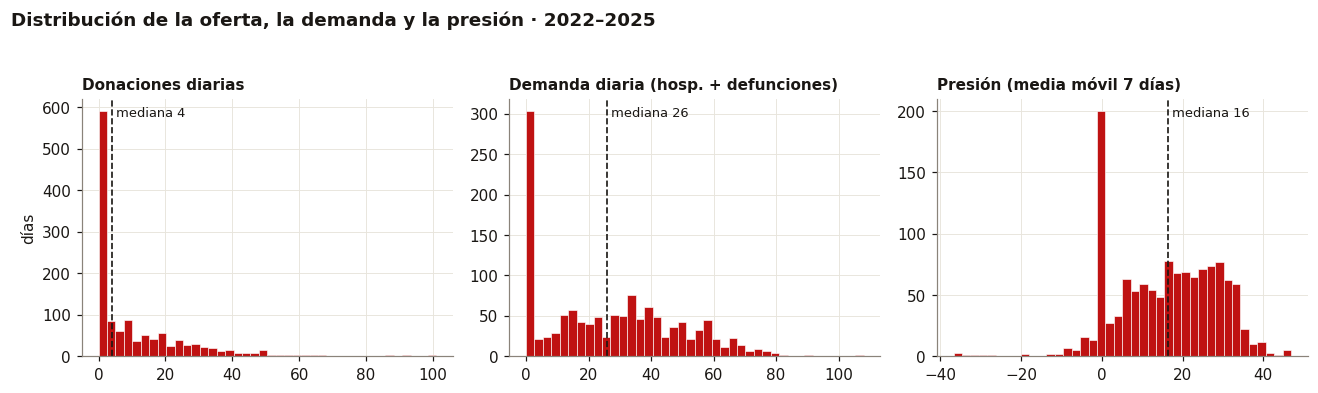

In [3]:
from src.data_pipeline.transform import build_daily_series

s = build_daily_series()
s["demanda"] = s["hospitalizados"] + s["muertes_sangre"]
s["presion"] = s["demanda"].rolling(7).mean() - s["donaciones"].rolling(7).mean()

paneles = [
    ("donaciones", "Donaciones diarias"),
    ("demanda", "Demanda diaria (hosp. + defunciones)"),
    ("presion", "Presión (media móvil 7 días)"),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (col, titulo) in zip(axes, paneles):
    datos = s[col].dropna()
    ax.hist(datos, bins=40, color=ROJO, edgecolor="white", linewidth=0.4)
    mediana = datos.median()
    ax.axvline(mediana, color=TINTA, linewidth=1.1, linestyle="--")
    ax.text(mediana, ax.get_ylim()[1] * 0.97, f" mediana {mediana:.0f}",
            fontsize=8.5, color=TINTA, va="top")
    ax.set_title(titulo, fontsize=10, loc="left", fontweight="bold")
    ax.set_ylabel("días" if col == "donaciones" else "")
fig.suptitle("Distribución de la oferta, la demanda y la presión · 2022–2025",
             x=0.005, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURAS / "distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()


La presión (demanda − oferta en media móvil de 7 días) es la señal que el modelo proyecta a 14 días: cuando supera el umbral τ hay escasez.

## Correlaciones entre las series

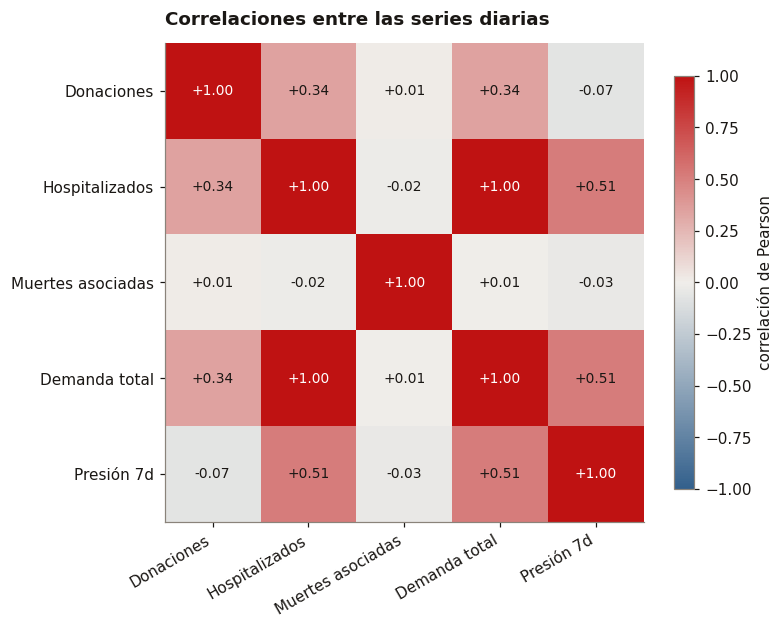

In [4]:
from matplotlib.colors import LinearSegmentedColormap

nombres = {
    "donaciones": "Donaciones", "hospitalizados": "Hospitalizados",
    "muertes_sangre": "Muertes asociadas", "demanda": "Demanda total",
    "presion": "Presión 7d",
}
corr = s[list(nombres)].dropna().corr()

# Paleta divergente: polo frío ↔ gris neutro ↔ polo cálido de la marca.
cmap = LinearSegmentedColormap.from_list("sang_div", ["#33608c", "#f0eeea", ROJO])

fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), [nombres[c] for c in corr.columns], rotation=30, ha="right")
ax.set_yticks(range(len(corr)), [nombres[c] for c in corr.index])
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.65 else TINTA)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlación de Pearson")
ax.set_title("Correlaciones entre las series diarias", loc="left",
             fontsize=12, fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig(FIGURAS / "correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()


## Matriz de confusión del modelo en test

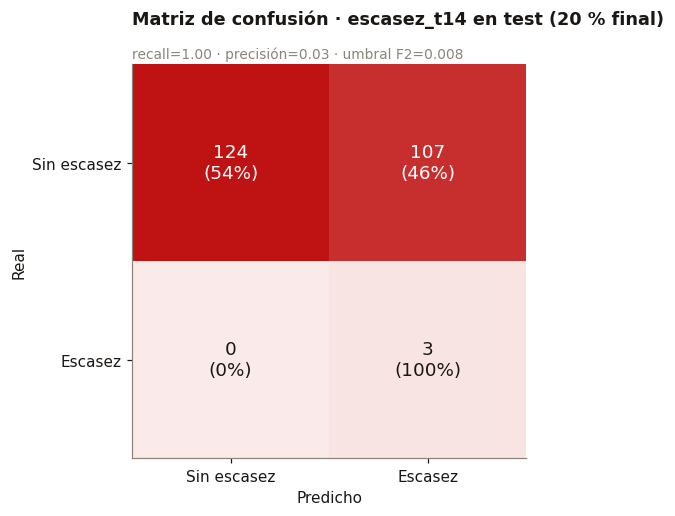

In [5]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from xgboost import XGBClassifier

from src.features.build_features import TEST_FRAC, build_model_frame
from src.train import umbral_oof

# Evaluación honesta: entrenar solo con el 80 % inicial y medir en el 20 % final.
m, features, tau = build_model_frame()
split = int(len(m) * (1 - TEST_FRAC))
X_tr, y_tr = m[features].iloc[:split], m["escasez_t14"].iloc[:split]
X_te, y_te = m[features].iloc[split:], m["escasez_t14"].iloc[split:]

spw = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())
model = XGBClassifier(
    n_estimators=400, max_depth=3, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=42, eval_metric="logloss", scale_pos_weight=spw,
)
model.fit(X_tr, y_tr)
umbral = umbral_oof(model, X_tr, y_tr)
pred = (model.predict_proba(X_te)[:, 1] >= umbral).astype(int)

cm = confusion_matrix(y_te, pred)
recall = recall_score(y_te, pred, zero_division=0)
precision = precision_score(y_te, pred, zero_division=0)

cmap_sec = LinearSegmentedColormap.from_list("sang_sec", ["#fbeaea", ROJO])
clases = ["Sin escasez", "Escasez"]

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(cm, cmap=cmap_sec)
ax.set_xticks([0, 1], clases)
ax.set_yticks([0, 1], clases)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.grid(False)
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / cm[i].sum() if cm[i].sum() else 0
        ax.text(j, i, f"{cm[i, j]}\n({pct:.0%})", ha="center", va="center",
                fontsize=12, color="white" if cm[i, j] > cm.max() * 0.6 else TINTA)
ax.set_title("Matriz de confusión · escasez_t14 en test (20 % final)",
             loc="left", fontsize=11.5, fontweight="bold", pad=26)
ax.text(0, 1.015, f"recall={recall:.2f} · precisión={precision:.2f} · umbral F2={umbral:.3f}",
        transform=ax.transAxes, fontsize=9, color=GRIS)
fig.tight_layout()
fig.savefig(FIGURAS / "matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


El umbral de decisión se elige maximizando **F2** (prioriza recall): en un banco de sangre, no ver una escasez cuesta más que una falsa alarma.

## Reporte de estado del agente analista

In [6]:
from src.agents.analyst_agent import REPORT_PATH, build_report, main

main()  # escribe reports/reporte_estado.md
print(build_report()[:900])


Reporte escrito en reports\reporte_estado.md
# Reporte de estado — Banco de Sangre HGM

*Generado automáticamente por `src/agents/analyst_agent.py` el 2026-07-09 19:05 UTC (datos hasta 2025-06-13).*

## Situación general: 🟢 Normal

- **Presión actual** (demanda − oferta, media 7d): 8.3 frente a un umbral τ = 28.6.
- **Riesgo de escasez a 14 días**: 0.1%.
- Presión media de los últimos 30 días: 11.3; días en alerta del modelo: 0 de 30.
- Donaciones del último día registrado: 20.

## Stock por grupo sanguíneo

| Tipo | Unidades | Mínimo seguro | Estado |
|---|--:|--:|---|
| O+ | 752 | 263 | OK |
| A+ | 357 | 124 | OK |
| O- | 126 | 44 | OK |
| B+ | 90 | 31 | OK |
| A- | 39 | 20 | OK |
| AB+ | 22 | 20 | OK |
| B- | 11 | 20 | ⚠️ bajo mínimo |
| AB- | 3 | 20 | ⚠️ bajo mínimo |

## Campañas registradas

| Fecha | Comuna | Campaña | Estado |
|---|---|---|---|
| 2025-06-18 | Bello | Jornada móvil — parque principal | programada |
| 2025-06
